# Kaggle Housing Price Prediction - Boosted Tree Model
Notebook for the *Housing Prices Competition for Kaggle Learn Users*

Some functions in this notebook use findings from data exploration in the data-exploration.ipynb notebook.

Data processing here is based on the data exploration performed in the data-exploration.ipynb notebook.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

from pandas.api.types import CategoricalDtype

from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression

from xgboost import XGBRegressor

import joblib
import plotly
import optuna
import optuna.visualization as vis

# set global theme and disable frames
sns.set_theme(style = 'white',
              rc={'legend.frameon': False},
              )
sns.set_style('ticks', {'xtick.major.size' : 8,
                        'ytick.major.size' : 8,
                        'xtick.bottom'     : True,
                        'ytick.left'       : True,
                        })

## Set up Preprocessing Functions
This includes cleaning and imputing all data and then encoding the categorical variables

Based on data exploration in data-exploration.ipynb notebook

In [2]:
def clean(df):
    '''
    Applies preliminary data cleaning to the provided
    dataframe based on the cells above
    '''
    # set missing GarageYrBlt values to YearBuilt
    df.loc[df['GarageYrBlt'] < df['YearBuilt'], 'GarageYrBlt'] = df['YearBuilt']

    return df


def remove_outliers(df):
    '''
    Two Edwards neighbourhood partial sales identified in data-exploration.ipynb that
    seem like outliers. Large area, good quality, but low price. Remove these
    from the training data
    '''
    mask = ((df['Neighborhood'] == 'Edwards') &
            (df['SaleCondition'] == 'Partial') &
            (df['GrLivArea'] > 4000))
    
    return df[~mask]


def impute(df, impute_stats=None):
    '''
    Impute the columns in the provided dataframe
    based on the results of the cells above

    impute_stats is a dict that specifies values to
    use for imputing that need to be collected from
    training data 
    '''
    # first handle special cases

    # estimate missing LotFrontage by the root of LotArea
    df['RootArea']    = np.sqrt(df['LotArea'])
    df['LotFrontage'] = df['LotFrontage'].fillna(df['RootArea'])
    df = df.drop(columns=['RootArea'])

    # set missing GarageYrBlt with YearBuilt
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

    # impute the missing Electrical data with the mode
    if impute_stats is None:
        impute_stats = {'Electrical' : df['Electrical'].mode()[0]}
    
    df['Electrical'] = df['Electrical'].fillna(impute_stats['Electrical'])


    # general handling for the rest of the columns
    for col in df.select_dtypes('object', 'category'):
        df[col] = df[col].fillna('NA')
    
    for col in df.select_dtypes('number'):
        df[col] = df[col].fillna(0)
    
    return df, impute_stats


def encode(df):
    '''
    Encode the categorical columns of the provided dataframe
    based on the encoding outlined below
    '''
    # categorical columns
    categorical_cols = set(df.select_dtypes('object', 'category').columns)

    nominative_cols = ['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities',
                    'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
                    'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
                    'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'Functional',
                    'MiscFeature', 'SaleType', 'SaleCondition', 'GarageType']

    ordinal_cols = list(categorical_cols - set(nominative_cols))

    ordinal_encoding = {'LotShape'      : ['Reg', 'IR1', 'IR2', 'IR3'],
                        'LandSlope'     : ['Gtl', 'Mod', 'Sev'],
                        'ExterQual'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'ExterCond'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtQual'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtCond'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtExposure'  : ['No', 'Mn', 'Av', 'Gd'],
                        'BsmtFinType1'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'BsmtFinType2'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'HeatingQC'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'CentralAir'    : ['N', 'Y'],
                        'KitchenQual'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'FireplaceQu'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageQual'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageCond'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageFinish'  : ['Unf', 'RFn', 'Fin'],
                        'PavedDrive'    : ['N', 'P', 'Y'],
                        'PoolQC'        : ['Fa', 'TA', 'Gd', 'Ex'],
                        'Fence'         : ['MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
                        }

    ordinal_encoding = {key: ['NA'] + values for key, values in ordinal_encoding.items()}

    for col in nominative_cols:
        df[col] = df[col].astype('category')
    
    for col in ordinal_cols:
        df[col] = df[col].astype(CategoricalDtype(ordinal_encoding[col], ordered=True))
    
    return df

## Load Data and Apply Preprocessing

In [3]:
def load_data():
    # Load the Kaggle dataset
    path_train = './input/train.csv.gz'
    path_test  = './input/test.csv.gz'

    train_full = pd.read_csv(path_train, compression='gzip', index_col='Id')
    test_full  = pd.read_csv(path_test, compression='gzip', index_col='Id')

    train = train_full.copy()
    train = clean(train)
    train = remove_outliers(train)
    train, impute_stats = impute(train)
    train = encode(train)

    test = test_full.copy()
    test = clean(test)
    test, _ = impute(test, impute_stats)
    test = encode(test)

    return train, test

train, test = load_data()

print(f'Shape of train dataset: {train.shape}')
print(f'Shape of test dataset:  {test.shape}')

# remove training rows with missing target (SalePrice)
print(f'{train["SalePrice"].isna().sum()} trainig rows have a missing SalePrice')
train = train.dropna(subset=['SalePrice']) # no missing SalePrice so not needed

# remove any duplicate training rows
print(f'{train.duplicated().sum()} trainig rows are duplicates')
train = train.drop_duplicates(keep='first') # no duplicates so not needed

Shape of train dataset: (1458, 80)
Shape of test dataset:  (1459, 79)
0 trainig rows have a missing SalePrice
0 trainig rows are duplicates


## Make Baseline Model

In [4]:
def score_model(X, y, model=XGBRegressor(enable_categorical=True, random_state=123)):
    '''
    Return a score using cross validation to estimate
    model performance. This competition uses RMSE between
    log prices so use that as a metric
    '''    
    log_y = np.log(y)
    score = cross_val_score(model, X, log_y, cv=5, scoring='neg_mean_squared_error')
    score = -1 * score.mean()
    score = np.sqrt(score)

    return score

In [9]:
X = train.copy()
y = X.pop('SalePrice')

baseline_score = score_model(X, y)
print(f'Baseline model score: {baseline_score:.5f} RMSE')

Baseline model score: 0.13348 RMSE


## Investigate Utility Scores using Mutual Information

In [6]:
def get_mi_scores(X, y):
    '''
    Calculate mutual information scores between columns
    in X and target in y
    '''
    X = X.copy()
    for col in X.select_dtypes(['category']):
        X[col] = X[col].cat.codes

    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=123)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)

    return mi_scores


def plot_mi_scores(scores):
    '''
    Create a bar plot of mutual information scores
    '''
    scores = scores.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(4, 12))

    sns.barplot(x=scores.values, y=scores.index)

    ax.tick_params(axis='both', labelsize=8)
    ax.set_ylabel('Column')
    ax.set_xlabel('Mutual Information Score')
    
    plt.show()

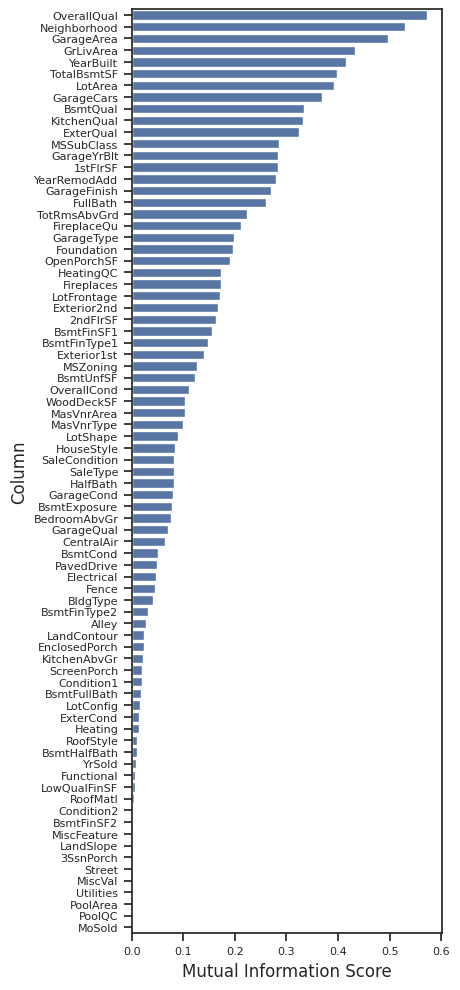

In [7]:
X = train.copy()
y = X.pop('SalePrice')

mi_scores = get_mi_scores(X, y)
plot_mi_scores(mi_scores)

In [10]:
# Delete columns with 0 mutual information so model isn't overfitting.
# Some columns like Poolxxx are mostly 0 or NA because most houses
# don't have pools

def drop_uninformative(df, mi_scores):
    return df.loc[:, mi_scores > 0.0]

X = train.copy()
y = X.pop('SalePrice')
X = drop_uninformative(X, mi_scores)

print(f'Score after removing uninformative features: {score_model(X, y):.5f} RMSE')

Score after removing uninformative features: 0.13606 RMSE


## Engineer Additional Features to Improve Model Score

In [11]:
def combinations(df):
    '''
    Creates a dataframe of new columns X which
    are meaningful mathematical transformations
    of the columns in df 
    '''
    X = pd.DataFrame(index=df.index)

    # ratios
    X['LivLotRatio']   = df['GrLivArea'] / df['LotArea'] # size of house vs size of property
    X['PorchLotRatio'] = df[['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']].sum(axis=1) / df['LotArea'] # how much of the lot is covered by decks
    X['Spaciousness']  = (df['1stFlrSF'] + df['2ndFlrSF']) / df['TotRmsAbvGrd'] # are the rooms spacious

    # products
    X['QualArea']     = df['OverallQual'] * df['GrLivArea'] # more area of higher quality should be more expensive

    # totals
    X['TotBath']      = df[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * df[['BsmtHalfBath', 'HalfBath']].sum(axis=1) # total bathroom count
    X['TotalSF']      = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'] # total interior SF

    # ages
    X['Age']          = df['YrSold'] - df['YearBuilt'] # how old is the house explicitly (newer houses should be more expensive?)
    X['AgeOfRemod']   = df['YrSold'] - df['YearRemodAdd'] # how old is the remodel (more recent also more expensive?)

    # flags
    X['HasGarage']    = (~df['GarageYrBlt'].isna()).astype(int) # is there a garage?
    X['HasBasement']  = (~df['TotalBsmtSF'].eq(0)).astype(int) # is there a basement?

    return X


def group_transforms(df, group_stats=None):
    '''
    Creates a dataframe of new columns which are group-level
    statistics per Neighborhood, computed from training data only.

    group_stats: dict of pre-computed Series (fit on train).
                 If None, stats are computed from df — only pass
                 None when df is the training set.
    '''
    if group_stats is None:
        group_stats = {
            'MedNhbdLivArea'  : df.groupby('Neighborhood', observed=False)['GrLivArea'].median(),
            'StdvNhbdLivArea' : df.groupby('Neighborhood', observed=False)['GrLivArea'].std(),
            'MeanNhbdLotArea' : df.groupby('Neighborhood', observed=False)['LotArea'].mean(),
        }

    X = pd.DataFrame(index=df.index)
    X['MedNhbdLivArea']  = df['Neighborhood'].map(group_stats['MedNhbdLivArea']).astype(float)
    X['StdvNhbdLivArea'] = df['Neighborhood'].map(group_stats['StdvNhbdLivArea']).astype(float)
    X['MedNhbdLivDiff']  = df['GrLivArea'] - X['MedNhbdLivArea']
    X['MeanNhbdLotArea'] = df['Neighborhood'].map(group_stats['MeanNhbdLotArea']).astype(float)

    return X, group_stats

In [ ]:
X = train.copy()
y = X.pop('SalePrice')

# X = drop_uninformative(X, mi_scores) # removing these columns seems to make the score worse
X = X.join(combinations(X))

group_features, group_stats = group_transforms(X)
X = X.join(group_features)

print(f'Model score: {score_model(X, y):.5f} RMSE')

Model score: 0.13032 RMSE


## Create Final Feature Set

In [14]:
def create_features(df, df_test=None):
    '''
    Combined function to set up all the model features based on
    Feature Engineering for Housing Prices Kaggle notebook
    '''
    X = df.copy()
    y = X.pop('SalePrice')

    mi_scores = get_mi_scores(X, y)

    # Choose not to combine splits to avoid leakage of test data
    # into train data. This would probably give better performance
    # for the Kaggle competition but probably not good when
    # making a general model that is supposed to predict unseen data

    # X = drop_uninformative(X, mi_scores) # seems to make the model perform worse
    X = X.join(combinations(X))

    group_features, group_stats = group_transforms(X)
    X = X.join(group_features)

    # set up test data
    if df_test is not None:
        X_test = df_test.copy()

        X_test = drop_uninformative(X_test, mi_scores)
        X_test = X_test.join(combinations(X_test))

        test_group_features, _ = group_transforms(X_test, group_stats)
        X_test = X_test.join(test_group_features)

        return X, X_test
    else:
        return X

## Tune XGBoost Hyperparameters with Optuna
Optuna uses Bayesian optimization where each trial informs the next so it's probably better than a random search in the XGBoost parameter space

In [15]:
df_train, df_test = load_data()
X_train = create_features(df_train)
y_train = df_train['SalePrice']

log_y_train = np.log(y_train)

In [16]:
def objective(trial):
    params = {'n_estimators'     : trial.suggest_int('n_estimators', 500, 2000),
              'learning_rate'    : trial.suggest_float('learning_rate', 0.0001, 0.2, log=True),
              'max_depth'        : trial.suggest_int('max_depth', 3, 10),
              'subsample'        : trial.suggest_float('subsample', 0.2, 1.0),
              'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.2, 1.0),
              'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
              'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
              'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
              }

    model = XGBRegressor(**params, enable_categorical=True, random_state=123)

    # this method doesn't take advantage of early_stopping_rounds so keep an eye on
    # n_estimators to make sure the model isn't using all the trees and overfitting
    scores = cross_val_score(model, X_train, log_y_train, cv=5, scoring='neg_mean_squared_error')

    return np.sqrt(-scores.mean())

In [17]:
# load cached study
# study = joblib.load('./optuna-cache/xgb-optuna-study.joblib')

# rerun study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# # cache hyperparameter optimization so it doesn't have to rerun
# joblib.dump(study, './optuna-cache/xgb-optuna-study.joblib')

print(f'Best RMSE:   {study.best_value:.5f}')
print(f'Best params: {study.best_params}')

[I 2026-06-13 12:15:25,672] A new study created in memory with name: no-name-43e91315-11bf-4d2b-ad8a-adab26f51c5b
[I 2026-06-13 12:28:27,399] Trial 0 finished with value: 0.1434624329681195 and parameters: {'n_estimators': 1466, 'learning_rate': 0.0013017692120315142, 'max_depth': 8, 'subsample': 0.44637328507744556, 'colsample_bytree': 0.5987949771635854, 'min_child_weight': 2, 'reg_alpha': 0.02366454021008311, 'reg_lambda': 0.061136173934365164}. Best is trial 0 with value: 0.1434624329681195.
[W 2026-06-13 12:31:44,073] Trial 1 failed with parameters: {'n_estimators': 1326, 'learning_rate': 0.1093787712590461, 'max_depth': 7, 'subsample': 0.7471569166290615, 'colsample_bytree': 0.8060478117885146, 'min_child_weight': 10, 'reg_alpha': 2.7147436755075716, 'reg_lambda': 0.7703064365892331} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/pone/kaggle/housing-prices/venv-housing/lib/python3.10/site-packages/optuna/study/_optimize.py", 

KeyboardInterrupt: 

In [30]:
# how the objective value improved over trials
vis.plot_optimization_history(study).show()

In [31]:
# which hyperparameters mattered most
vis.plot_param_importances(study).show()

In [33]:
# 2D slice of the objective surface
vis.plot_contour(study, params=['learning_rate', 'reg_alpha']).show()

In [34]:
# distribution of sampled values vs objective score
vis.plot_slice(study).show()

## Generate Predictions

In [33]:
X_train, X_test = create_features(df_train, df_test)
y_train         = df_train['SalePrice']

xgb = XGBRegressor(**study.best_params, enable_categorical=True)

# log transform because competition is looking at error in log price
xgb.fit(X_train, np.log(y_train))
predictions = np.exp(xgb.predict(X_test)) # convert log price back to regular price

output = pd.DataFrame({'Id': X_test.index,
                       'SalePrice': predictions,
                       })
output.to_csv('./output/xgb-submission.csv', index=False)

Dropping the following uninformative columns:
['PoolQC', 'MiscVal', 'MoSold']
Dropping the following uninformative columns:
['PoolQC', 'MiscVal', 'MoSold']
